Pandas with F1 data to make magic stuff happen

## Notebook Overview
This notebook demonstrates how to fetch data from the OpenF1 API, load it into a pandas DataFrame, and perform basic data exploration.

In [81]:
import requests

# url = "https://api.openf1.org/v1/drivers?session_key=latest"
# url = "https://api.openf1.org/v1/drivers?session_key=11299"
url = "https://api.openf1.org/v1/drivers?session_key=11326"

response = requests.get(url)
response.raise_for_status()

data = response.json()
# list of dictionaries
type(data)
data[:3]
# print(data[:3])  # print not usually needed when in a notebook

[{'meeting_key': 1289,
  'session_key': 11326,
  'driver_number': 1,
  'broadcast_name': 'L NORRIS',
  'full_name': 'Lando NORRIS',
  'name_acronym': 'NOR',
  'team_name': 'McLaren',
  'team_colour': 'F47600',
  'first_name': 'Lando',
  'last_name': 'Norris',
  'headshot_url': 'https://media.formula1.com/d_driver_fallback_image.png/content/dam/fom-website/drivers/L/LANNOR01_Lando_Norris/lannor01.png.transform/1col/image.png',
  'country_code': None},
 {'meeting_key': 1289,
  'session_key': 11326,
  'driver_number': 3,
  'broadcast_name': 'M VERSTAPPEN',
  'full_name': 'Max VERSTAPPEN',
  'name_acronym': 'VER',
  'team_name': 'Red Bull Racing',
  'team_colour': '4781D7',
  'first_name': 'Max',
  'last_name': 'Verstappen',
  'headshot_url': 'https://media.formula1.com/d_driver_fallback_image.png/content/dam/fom-website/drivers/M/MAXVER01_Max_Verstappen/maxver01.png.transform/1col/image.png',
  'country_code': None},
 {'meeting_key': 1289,
  'session_key': 11326,
  'driver_number': 5,
  '

In [82]:

url = "https://api.openf1.org/v1/sessions?session_key=11326"

response = requests.get(url)
response.raise_for_status()

session_data = response.json()
# list of dictionaries
type(session_data)
session_data[:3]
# print(data[:3])  # print not usually needed when in a notebook

[{'session_key': 11326,
  'session_type': 'Race',
  'session_name': 'Race',
  'date_start': '2026-07-05T14:00:00+00:00',
  'date_end': '2026-07-05T16:00:00+00:00',
  'meeting_key': 1289,
  'circuit_key': 2,
  'circuit_short_name': 'Silverstone',
  'country_key': 2,
  'country_code': 'GBR',
  'country_name': 'United Kingdom',
  'location': 'Silverstone',
  'gmt_offset': '01:00:00',
  'year': 2026,
  'is_cancelled': False}]

### Fetching Driver Data from OpenF1 API
This cell uses the `requests` library to make an API call to the OpenF1 API. Specifically, it fetches data for drivers from the latest session.

- `url`: Defines the endpoint for retrieving driver information.
- `requests.get(url)`: Sends an HTTP GET request to the specified URL.
- `response.raise_for_status()`: Checks if the request was successful. If not, it raises an HTTPError. We used something like "if response.status_code == 200:" last time... this is a built in feature of requests which can simplify things
- `response.json()`: Parses the JSON response into a Python list of dictionaries.
- `print(data[:3])`: Displays the first three entries of the fetched data to give a preview of its structure.

In [83]:
import pandas as pd

df = pd.DataFrame(data)

print(df.head())

   meeting_key  session_key  driver_number broadcast_name          full_name  \
0         1289        11326              1       L NORRIS       Lando NORRIS   
1         1289        11326              3   M VERSTAPPEN     Max VERSTAPPEN   
2         1289        11326              5    G BORTOLETO  Gabriel BORTOLETO   
3         1289        11326              6       I HADJAR       Isack HADJAR   
4         1289        11326             10        P GASLY       Pierre GASLY   

  name_acronym        team_name team_colour first_name   last_name  \
0          NOR          McLaren      F47600      Lando      Norris   
1          VER  Red Bull Racing      4781D7        Max  Verstappen   
2          BOR             Audi      F50537    Gabriel   Bortoleto   
3          HAD  Red Bull Racing      4781D7      Isack      Hadjar   
4          GAS           Alpine      00A1E8     Pierre       Gasly   

                                        headshot_url country_code  
0  https://media.formula1.com/

### Purpose of the `df` DataFrame
The `df` DataFrame holds the structured data retrieved from the OpenF1 API. It serves as the primary data structure for all subsequent data cleaning, analysis, and visualisation tasks in this notebook. By converting the raw JSON into a DataFrame, we can leverage pandas' powerful featiures for data manipulation and exploration.

### Converting Data to Pandas DataFrame
This cell converts the fetched raw JSON data (a list of dictionaries) into a pandas DataFrame for easier manipulation and analysis.

- `import pandas as pd`: Imports the pandas library.
- `df = pd.DataFrame(data)`: Creates a DataFrame named `df` from the `data` list.
- `print(df.head())`: Displays the first 5 rows of the DataFrame, providing a quick overview of the data and its columns.

In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   meeting_key     22 non-null     int64 
 1   session_key     22 non-null     int64 
 2   driver_number   22 non-null     int64 
 3   broadcast_name  22 non-null     object
 4   full_name       22 non-null     object
 5   name_acronym    22 non-null     object
 6   team_name       22 non-null     object
 7   team_colour     22 non-null     object
 8   first_name      22 non-null     object
 9   last_name       22 non-null     object
 10  headshot_url    22 non-null     object
 11  country_code    0 non-null      object
dtypes: int64(3), object(9)
memory usage: 2.2+ KB


### Data Overview: `df.info()`
This cell provides a concise summary of the DataFrame, including the data types of each column, the number of non-null values, and memory usage. This is crucial for identifying missing data and understanding column types.

- `df.info()`: Prints a summary of the DataFrame.

In [85]:
df.describe()

,meeting_key,session_key,driver_number
count,22.0,22.0,22.000000
mean,1289.0,11326.0,31.727273
std,0.0,0.0,26.461440
min,1289.0,11326.0,1.000000
25%,1289.0,11326.0,11.250000
50%,1289.0,11326.0,25.000000
75%,1289.0,11326.0,43.750000
max,1289.0,11326.0,87.000000


### Descriptive Statistics: `df.describe()`
Before we start analysing the data, it's useful to understand what values are available and whether anything looks unusual. df.describe() gives us a quick statistical summary of the numeric columns, helping us identify possible outliers, missing values, or unexpected ranges.

- `df.describe()`: Computes summary statistics for numeric columns.

In [86]:
df.columns

Index(['meeting_key', 'session_key', 'driver_number', 'broadcast_name',
       'full_name', 'name_acronym', 'team_name', 'team_colour', 'first_name',
       'last_name', 'headshot_url', 'country_code'],
      dtype='object')

### Column Names: `df.columns`
This cell displays all the column names present in the DataFrame. This is useful for quickly referencing column names for further data manipulation.

- `df.columns`: Returns an Index object containing the column labels of the DataFrame.

In [87]:
drivers_per_team = df.groupby('team_name').size().reset_index(name='number_of_drivers')
display(drivers_per_team)

,team_name,number_of_drivers
0,Alpine,2
1,Aston Martin,2
2,Audi,2
3,Cadillac,2
4,Ferrari,2
5,Haas F1 Team,2
6,McLaren,2
7,Mercedes,2
8,Racing Bulls,2
9,Red Bull Racing,2


### Drivers Per Team
This cell groups the DataFrame by `team_name` and counts the number of drivers in each team. This helps to understand the distribution of drivers across different teams.

- `df.groupby('team_name').size()`: Groups the DataFrame by the `team_name` column and counts the number of rows (drivers) in each group.
- `.reset_index(name='number_of_drivers')`: Converts the Series result into a DataFrame with a column named `number_of_drivers`.
- `display(drivers_per_team)`: Displays the resulting DataFrame.

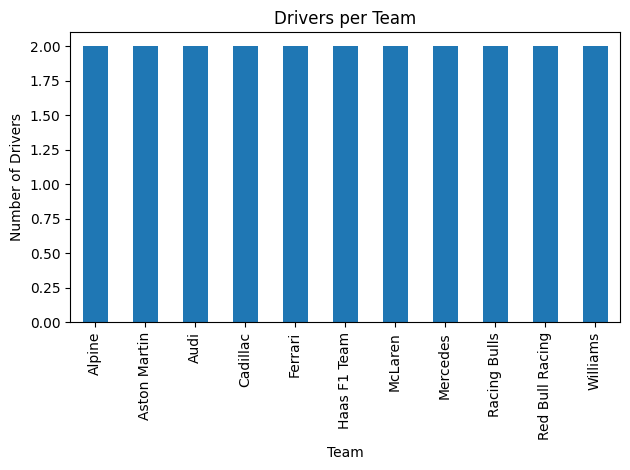

In [88]:
import matplotlib.pyplot as plt

drivers_per_team.plot(
    x='team_name',
    y='number_of_drivers',
    kind='bar',
    legend=False
)

plt.title('Drivers per Team')
plt.xlabel('Team')
plt.ylabel('Number of Drivers')
plt.tight_layout()
plt.show()

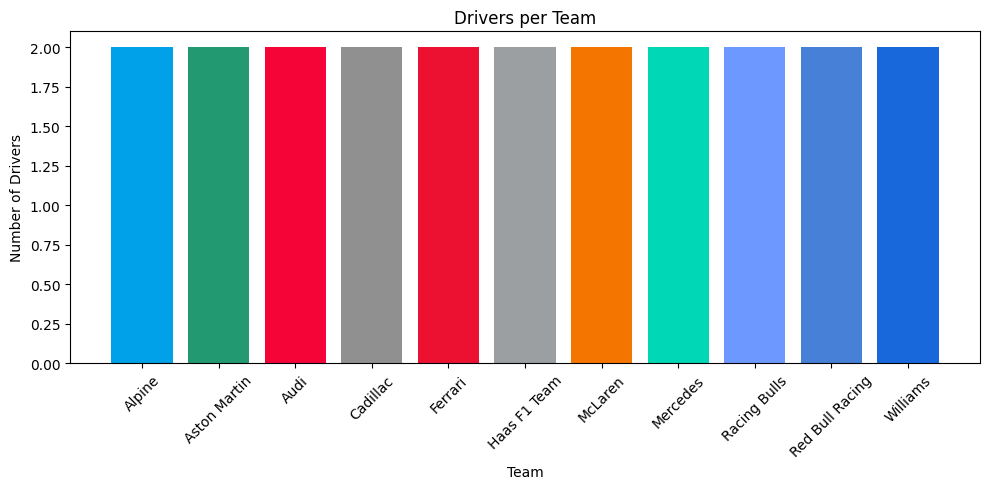

In [89]:
# Get unique team names and their corresponding colours from the original DataFrame
team_colors_map = df[['team_name', 'team_colour']].drop_duplicates().set_index('team_name')['team_colour']

# Add the 'team_colour' column to drivers_per_team by mapping
drivers_per_team['team_colour'] = drivers_per_team['team_name'].map(team_colors_map)

colours = [
    f"#{c}" for c in drivers_per_team["team_colour"]
]

plt.figure(figsize=(10, 5))

plt.bar(
    drivers_per_team["team_name"],
    drivers_per_team["number_of_drivers"],
    color=colours
)

plt.title("Drivers per Team")
plt.xlabel("Team")
plt.ylabel("Number of Drivers")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [90]:
# Fastest lap?

url = "https://api.openf1.org/v1/stints?session_key=latest"

response = requests.get(url)
response.raise_for_status()
stints = response.json()  # stints as a list of dict

stints[:3]

[{'meeting_key': 1286,
  'session_key': 11299,
  'stint_number': 1,
  'driver_number': 3,
  'lap_start': 1,
  'lap_end': 1,
  'compound': 'MEDIUM',
  'tyre_age_at_start': 0},
 {'meeting_key': 1286,
  'session_key': 11299,
  'stint_number': 1,
  'driver_number': 5,
  'lap_start': 1,
  'lap_end': 0,
  'compound': 'SOFT',
  'tyre_age_at_start': 0},
 {'meeting_key': 1286,
  'session_key': 11299,
  'stint_number': 1,
  'driver_number': 77,
  'lap_start': 1,
  'lap_end': 0,
  'compound': 'SOFT',
  'tyre_age_at_start': 0}]

### Fetching Stint Data from OpenF1 API
This cell fetches data related to 'stints' from the OpenF1 API. Stints refer to a continuous period a driver spends on track with a particular set of tires between pit stops.

- `url`: Defines the endpoint for retrieving stint information.
- `requests.get(url)`: Sends an HTTP GET request to the specified URL.
- `response.raise_for_status()`: Checks if the request was successful; raises an HTTPError for bad responses.
- `stints = response.json()`: Parses the JSON response into a Python list of dictionaries, storing it as `stints`.
- `stints[:3]`: Displays the first three entries of the fetched stint data to provide a preview.

In [91]:
stints = pd.DataFrame(response.json())

type(stints)

pandas.core.frame.DataFrame

In [92]:
stints

,meeting_key,session_key,stint_number,driver_number,lap_start,lap_end,compound,tyre_age_at_start
0,1286,11299,1,3,1,1,MEDIUM,0
1,1286,11299,1,5,1,0,SOFT,0
2,1286,11299,1,77,1,0,SOFT,0
3,1286,11299,1,87,1,0,MEDIUM,0
4,1286,11299,1,14,1,2,MEDIUM,0
...,...,...,...,...,...,...,...,...
103,1286,11299,7,11,68,78,SOFT,0
104,1286,11299,7,14,68,78,SOFT,8
105,1286,11299,8,5,68,78,SOFT,0
106,1286,11299,6,63,72,78,SOFT,8


### Converting Stint Data to Pandas DataFrame
This cell converts the fetched raw JSON stint data (a list of dictionaries) into a pandas DataFrame for easier manipulation and analysis.

- `stints = pd.DataFrame(response.json())`: Creates a DataFrame named `stints` from the `response.json()` data.

In [93]:
stints["laps_on_tyre"] = (
    stints["lap_end"] -
    stints["lap_start"] + 1
)

stints.head()

,meeting_key,session_key,stint_number,driver_number,lap_start,lap_end,compound,tyre_age_at_start,laps_on_tyre
0,1286,11299,1,3,1,1,MEDIUM,0,1
1,1286,11299,1,5,1,0,SOFT,0,0
2,1286,11299,1,77,1,0,SOFT,0,0
3,1286,11299,1,87,1,0,MEDIUM,0,0
4,1286,11299,1,14,1,2,MEDIUM,0,2


### Calculating Laps on Tyre for Each Stint
This cell calculates the number of laps completed on a specific tire compound during each stint. This is a crucial metric for analysing tire degradation and strategy.

- `stints["laps_on_tyre"] = (stints["lap_end"] - stints["lap_start"] + 1)`: Calculates the number of laps in a stint by subtracting the `lap_start` from `lap_end` and adding 1 (to include both the start and end laps).
- `stints.head()`: Displays the first few rows of the updated `stints` DataFrame, showing the new `laps_on_tyre` column.

In [94]:
avg_stint_length = (
    stints.groupby("compound")["laps_on_tyre"]
          .mean()
          .sort_values(ascending=False)
)

avg_stint_length

,laps_on_tyre
compound,
MEDIUM,24.576923
HARD,17.130435
SOFT,7.000000


### Average Stint Length by Tyre Compound
This cell calculates the average number of laps completed for each tire compound. This helps in understanding which compounds are typically used for longer or shorter stints.

- `stints.groupby("compound")["laps_on_tyre"].mean()`: Groups the `stints` DataFrame by `compound` (tire type) and calculates the mean of `laps_on_tyre` for each group.
- `.sort_values(ascending=False)`: Sorts the results in descending order, showing the compounds with the longest average stints first.
- `avg_stint_length`: Displays the resulting Series.

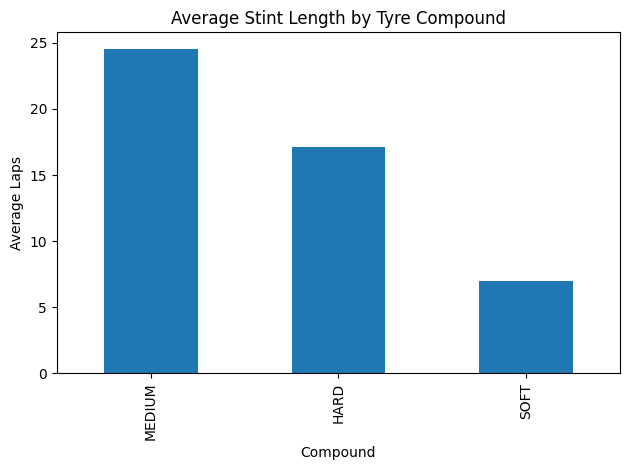

In [95]:
import matplotlib.pyplot as plt

avg_stint_length.plot(
    kind="bar",
    title="Average Stint Length by Tyre Compound"
)

plt.xlabel("Compound")
plt.ylabel("Average Laps")
plt.tight_layout()
plt.show()

### Visualising Average Stint Length by Tyre Compound
This cell generates a bar chart to visually represent the average stint length for each tire compound. This provides a clear and quick way to compare tire performance.

- `avg_stint_length.plot(kind="bar", title="Average Stint Length by Tyre Compound")`: Creates a bar plot from the `avg_stint_length` Series with a descriptive title.
- `plt.xlabel("Compound")` and `plt.ylabel("Average Laps")`: Set the labels for the x and y axes.
- `plt.tight_layout()`: Adjusts plot parameters for a tight layout.
- `plt.show()`: Displays the generated plot.

In [96]:
stints.nlargest(
    10,
    "laps_on_tyre"
)[[
    "driver_number",
    "compound",
    "laps_on_tyre"
]]

,driver_number,compound,laps_on_tyre
34,41,MEDIUM,58
29,14,SOFT,55
25,18,SOFT,53
24,55,MEDIUM,51
38,31,HARD,50
47,11,MEDIUM,50
23,81,MEDIUM,47
26,27,HARD,46
22,10,MEDIUM,44
18,1,MEDIUM,43


### Top 10 Longest Stints
This cell identifies and displays the top 10 longest stints recorded in the dataset, showing the driver number, tyre compound, and the number of laps completed.

- `stints.nlargest(10, "laps_on_tyre")`: Selects the 10 rows with the largest values in the `laps_on_tyre` column.
- `[["driver_number", "compound", "laps_on_tyre"]]`: Selects only the `driver_number`, `compound`, and `laps_on_tyre` columns for display.

In [97]:
stints["laps_on_tyre"].describe()

,laps_on_tyre
count,108.000000
mean,13.388889
std,15.673559
min,0.000000
25%,2.000000
50%,6.000000
75%,16.000000
max,58.000000


### Descriptive Statistics for Laps on Tyre
This cell provides descriptive statistics for the `laps_on_tyre` column, offering insights into the distribution, central tendency, and spread of stint lengths.

- `stints["laps_on_tyre"].describe()`: Computes summary statistics (count, mean, standard deviation, min, max, quartiles) for the `laps_on_tyre` column.

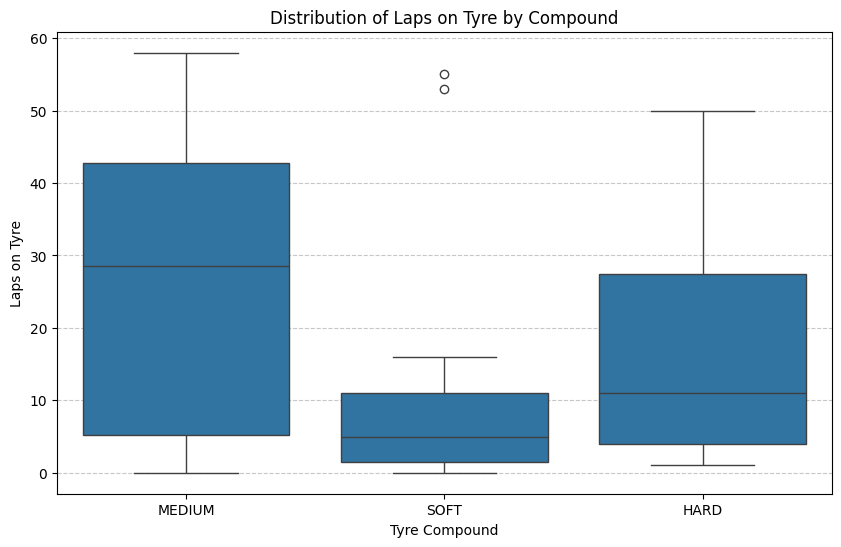

In [98]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.boxplot(x='compound', y='laps_on_tyre', data=stints)
plt.title('Distribution of Laps on Tyre by Compound')
plt.xlabel('Tyre Compound')
plt.ylabel('Laps on Tyre')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Box Plot: Distribution of Laps on Tyre by Compound
This box plot visualises the distribution of `laps_on_tyre` for each `compound`. Box plots are useful for observing the spread and central tendency of data, as well as identifying potential outliers.

- `plt.figure(figsize=(10, 6))`: Sets the size of the plot.
- `sns.boxplot(x='compound', y='laps_on_tyre', data=stints)`: Creates the box plot, with 'compound' on the x-axis and 'laps_on_tyre' on the y-axis, using the `stints` DataFrame.
- `plt.title()`, `plt.xlabel()`, `plt.ylabel()`: Set the title and axis labels for clarity.
- `plt.grid()`: Adds a grid for better readability.
- `plt.show()`: Displays the plot.

In [99]:
avg_laps_per_driver = stints.groupby('driver_number')['laps_on_tyre'].mean()
highest_avg_laps_driver = avg_laps_per_driver.idxmax()
max_avg_laps = avg_laps_per_driver.max()

print(f"Driver with the highest average laps on tyre per stint: Driver Number {highest_avg_laps_driver} with an average of {max_avg_laps:.2f} laps.")

Driver with the highest average laps on tyre per stint: Driver Number 1 with an average of 43.00 laps.


/tmp/ipykernel_60141/3592671698.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tyre_compound_frequency.index, y=tyre_compound_frequency.values, palette='viridis')


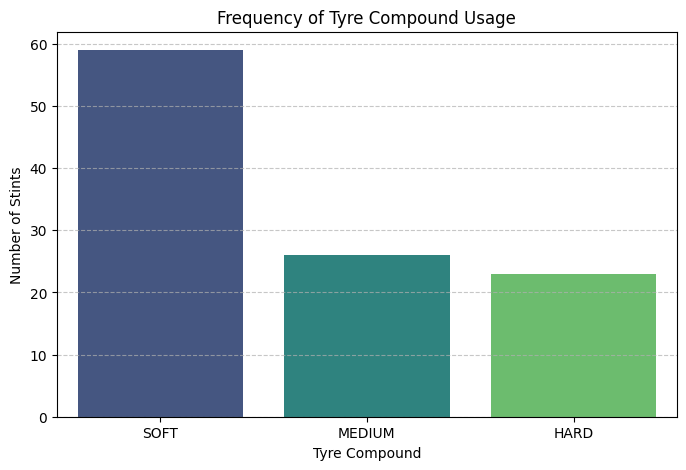

In [100]:
tyre_compound_frequency = stints['compound'].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(x=tyre_compound_frequency.index, y=tyre_compound_frequency.values, palette='viridis')
plt.title('Frequency of Tyre Compound Usage')
plt.xlabel('Tyre Compound')
plt.ylabel('Number of Stints')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Frequency of Tyre Compound Usage
This bar chart illustrates how frequently each tyre compound was used during the race. This can provide insights into team strategies and the performance characteristics of each compound.

- `tyre_compound_frequency = stints['compound'].value_counts()`: Counts the occurrences of each unique value in the 'compound' column, effectively getting the frequency of each tyre type.
- `plt.figure(figsize=(8, 5))`: Sets the size of the plot.
- `sns.barplot(x=tyre_compound_frequency.index, y=tyre_compound_frequency.values, palette='viridis')`: Creates a bar plot using the compound names as x-axis labels and their counts as y-axis values. `palette='viridis'` applies a colour scheme.
- `plt.title()`, `plt.xlabel()`, `plt.ylabel()`: Set the title and axis labels for clarity.
- `plt.grid()`: Adds a grid for better readability.
- `plt.show()`: Displays the plot.

### Driver with Highest Average Laps on Tyre per Stint
This cell calculates and identifies the driver who completed the highest average number of laps per stint.

- `avg_laps_per_driver = stints.groupby('driver_number')['laps_on_tyre'].mean()`: Groups the `stints` DataFrame by `driver_number` and computes the average `laps_on_tyre` for each driver.
- `highest_avg_laps_driver = avg_laps_per_driver.idxmax()`: Finds the `driver_number` (index) corresponding to the maximum average `laps_on_tyre`.
- `max_avg_laps = avg_laps_per_driver.max()`: Retrieves the maximum average `laps_on_tyre` value.
- `print(...)`: Displays the driver number and their average laps.